## Number of eigenvalues of cell covariance matrix which follow power-law
Here, we calculate eigenspectra of cell covariance matrix.Thereafter, we plot the log(eigenvalues) versus log(rank of eigenvalue) and find out the number of eigenvalues n which fall on a power-law. 

In [1]:
#call necessary libraries
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import os #For file handling

#### Importing experimental scRNA-seq data

In [2]:
PATH = os.path.expanduser('~') + '/Dropbox/suvranil/cellmem'

In [3]:
df = pd.read_csv(PATH + '/data/MemSeqData/HighVariable3000CountMatrix_batch_1.csv')
df

,gene,AAACGCTTCCGGACGT-1,AAAGGGCTCAGACAAA-1,AAAGTCCGTCCTCAGG-1,AAAGTGAGTGAGTGAC-1,AAAGTGAGTGTGCTTA-1,AAAGTGATCAAACGAA-1,AAATGGATCAAGTGTC-1,AACAAAGAGGCCCAAA-1,AACAACCCACAGTCGC-1,...,TTTGGAGCACCTGATA-4,TTTGGAGTCCTGGGAC-4,TTTGGAGTCTTAGTTC-4,TTTGGTTAGACGAGCT-4,TTTGGTTAGACTGAGC-4,TTTGGTTAGATTGGGC-4,TTTGGTTGTTGTATGC-4,TTTGTTGAGATGGCAC-4,TTTGTTGGTGTGATGG-4,TTTGTTGTCTGGTGCG-4
0,PRR9,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,DKK1,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2,CCL5,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
3,OASL,0.000007,0.000013,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
4,PTGS2,0.000007,0.000000,0.000110,0.00000,0.0,0.0,0.0,0.000000,0.000009,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,ASB2,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000035,0.000037,0.000000
2996,SH3RF1,0.000000,0.000013,0.000022,0.00001,0.0,0.0,0.0,0.000000,0.000009,...,0.0,0.000000,0.0,0.000021,0.0,0.0,0.0,0.000000,0.000000,0.000000
2997,AL158835.1,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000027,0.000000,...,0.0,0.000033,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2998,HBQ1,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000017,0.000000,0.000019


In [4]:
df1 = df.iloc[: , 1 : ]
df1

,AAACGCTTCCGGACGT-1,AAAGGGCTCAGACAAA-1,AAAGTCCGTCCTCAGG-1,AAAGTGAGTGAGTGAC-1,AAAGTGAGTGTGCTTA-1,AAAGTGATCAAACGAA-1,AAATGGATCAAGTGTC-1,AACAAAGAGGCCCAAA-1,AACAACCCACAGTCGC-1,AACACACGTACCGGCT-1,...,TTTGGAGCACCTGATA-4,TTTGGAGTCCTGGGAC-4,TTTGGAGTCTTAGTTC-4,TTTGGTTAGACGAGCT-4,TTTGGTTAGACTGAGC-4,TTTGGTTAGATTGGGC-4,TTTGGTTGTTGTATGC-4,TTTGTTGAGATGGCAC-4,TTTGTTGGTGTGATGG-4,TTTGTTGTCTGGTGCG-4
0,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
3,0.000007,0.000013,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000031,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
4,0.000007,0.000000,0.000110,0.00000,0.0,0.0,0.0,0.000000,0.000009,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000016,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000035,0.000037,0.000000
2996,0.000000,0.000013,0.000022,0.00001,0.0,0.0,0.0,0.000000,0.000009,0.000000,...,0.0,0.000000,0.0,0.000021,0.0,0.0,0.0,0.000000,0.000000,0.000000
2997,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000027,0.000000,0.000016,...,0.0,0.000033,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2998,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000017,0.000000,0.000019


#### Eigenspectra of original cell covariance matrix (n)

In [5]:
z = df1.values.T
#centralization and normalization
X_E = np.float32((z - np.mean(z, axis = 0)) / np.std(z, axis = 0))
print('Shape of data matrix is: ', X_E.shape)
ng = X_E.shape[1]
nc = X_E.shape[0]

Shape of data matrix is:  (7590, 3000)


In [6]:
#Calculating eigenspectra of original cell covarinace matrix
cv = np.matmul(X_E, X_E.T) / ng
ev = np.linalg.eigvalsh(cv)[::-1]
rank = np.linspace(1, nc, nc)

#### Find the threshold
Here, we estimate how many top eigenvalues are following power-law from a log(eigenvalues) versus log(rank of eigenvalue) plot. 
In our experience fitting a straight line through these n eigenvalues typically gives R^2 above 0.9. 

r-squared val is:  0.9


Text(0, 0.5, 'Eigenvalues')

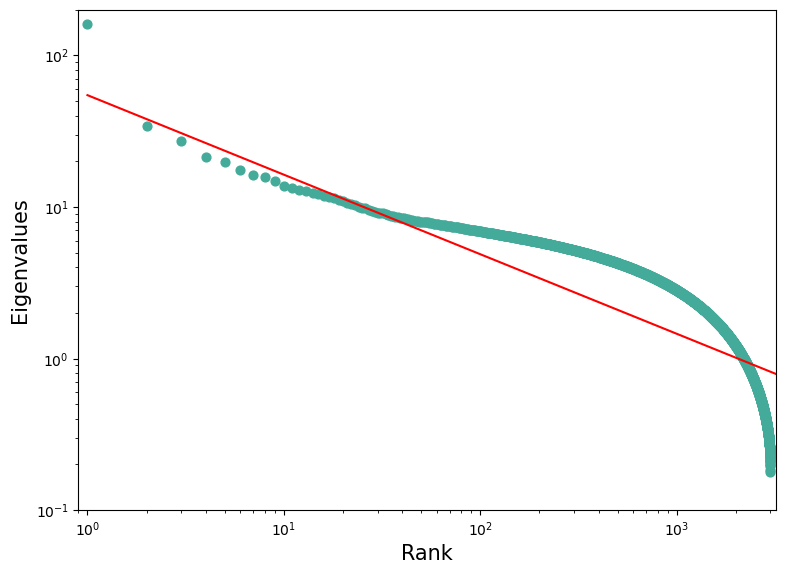

In [7]:
#vary this threhold for desired R^2 value
threshold = 50  
x_data = np.log(rank[: threshold])
y_data = np.log(ev[: threshold])
# fitting using linear regression
result = stats.linregress(x_data, y_data)
slope, intercept, r_val = result[0], result[1], result[2]
print('r-squared val is: ', np.round(r_val**2, 1))

# fitting data
x_fit_data = np.linspace(np.log(1), 10, 10)
y_fit_data = slope * x_fit_data + intercept

# for plotting in a log-log graph
exp_x_fit_data = np.exp(x_fit_data)
exp_y_fit_data = np.exp(y_fit_data)

f = plt.figure(figsize=(9, 6.5), dpi = 100)
ax = f.add_subplot()
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim(10**-1, 200)
ax.set_xlim(0.9, ng + 200)
ax.scatter(rank, ev,s = 40, color = '#44aa99', linewidth = 1.0)
ax.plot(exp_x_fit_data, exp_y_fit_data, c = 'red')
ax.set_xlabel('Rank',fontsize=15)
ax.set_ylabel('Eigenvalues',fontsize=15)

So, here we find threshold n is 50. We have to use the **value of n as input** in PowerSeekAlgorithmOnData.ipynb file.